In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv(r"C:\Users\User\Desktop\water\data\cleaned_stats.csv")

In [3]:
features = [
    'conductivity_of_solution_ mS_cm',
    'oxidation_reduction_potential_ mV',
    'oxygen_saturation_%',
    'turbidity_NTU'
]

features2 = ['oxidation_reduction_potential_ mV','turbidity_NTU']

sensor_id_col = "sensor_id"
label_col = "Water_Quality_Label"

# Feature weights
weights = {
    'conductivity_of_solution_ mS_cm': 1,
    'oxidation_reduction_potential_ mV': 1,
    'oxygen_saturation_%': 1,
    'turbidity_NTU': 2.5
}

#### Τυποποίηση

In [4]:
df_scaled = df.copy()

scaler = StandardScaler()

df_scaled[features] = scaler.fit_transform(
    df[features]
)


# Apply weights AFTER scaling
for feature, weight in weights.items():
    df_scaled[feature] *= weight

#### K-meams, για k = 2 και ανα αισθητήρα

In [17]:
processed_sensor_dfs = []


for sensor in df_scaled[sensor_id_col].unique():

    sensor_mask = df_scaled[sensor_id_col] == sensor
    
    sensor_data = df_scaled.loc[
        sensor_mask, features
    ]

    original_sensor_data = df.loc[
        sensor_mask
    ].copy()


    if len(sensor_data) < 3:
        continue


    kmeans = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=20
    )


    clusters = kmeans.fit_predict(sensor_data)


    original_sensor_data["cluster"] = clusters


    # Label clusters based on turbidity
    turbidity_order = (
        original_sensor_data
        .groupby("cluster")["turbidity_NTU"]
        .mean()
        .sort_values()
        .index
    )


    mapping = {
        turbidity_order[0]: "Ok",
        turbidity_order[1]: "Medium",
        #turbidity_order[2]: "Danger"
    }


    original_sensor_data["Water_Quality_Label"] = (
        original_sensor_data["cluster"]
        .map(mapping)
    )


    original_sensor_data.drop(
        columns="cluster",
        inplace=True
    )


    processed_sensor_dfs.append(
        original_sensor_data
    )


final_training_df = pd.concat(
    processed_sensor_dfs
)

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [18]:
overall_stats = (
    final_training_df
    .groupby(label_col)[features]
    .agg(["mean", "median", "std", "min", "max"])
)

overall_stats

conductivity_of_solution_ mS_cm                           \
                                               mean     median           std   
Water_Quality_Label                                                            
Medium                                  53773.22180  56529.485   8785.613150   
Ok                                      51237.23234  54544.095  10525.930058   

                                        oxidation_reduction_potential_ mV  \
                          min       max                              mean   
Water_Quality_Label                                                         
Medium               15018.65  71848.98                        103.209731   
Ok                   15564.93  77197.73                        166.016430   

                                                         oxygen_saturation_%  \
                      median         std     min     max                mean   
Water_Quality_Label                                                            
Medium                98.715  149.405363 -276.99  356.58           73.106935   
Ok                   256.775  170.918272 -288.34  359.98           71.528022   

                                                      turbidity_NTU           \
                     median        std    min     max          mean   median   
Water_Quality_Label                                                            
Medium               71.985  19.846699  27.55  141.12     388.63966  373.000   
Ok                   67.380  18.760658   4.19  151.80     122.25163  116.675   

                                               
                            std   min     max  
Water_Quality_Label                            
Medium               158.894810  1.62  899.14  
Ok                    96.815431  0.00  497.01

In [13]:
print("--- Overall Label Distribution ---")
print(final_training_df['Water_Quality_Label'].value_counts())

print("\n--- Feature Averages by Quality Label ---")
#profile_cols = [turbidity_col] + features_to_scale
print(final_training_df.groupby('Water_Quality_Label')[features].mean())

--- Overall Label Distribution ---
Water_Quality_Label
Ok        8551
Medium    5271
Name: count, dtype: int64

--- Feature Averages by Quality Label ---
                     conductivity_of_solution_ mS_cm  \
Water_Quality_Label                                    
Medium                                  53771.900787   
Ok                                      51238.343210   

                     oxidation_reduction_potential_ mV  oxygen_saturation_%  \
Water_Quality_Label                                                           
Medium                                      103.195625            73.123441   
Ok                                          166.017780            71.518032   

                     turbidity_NTU  
Water_Quality_Label                 
Medium                  388.629067  
Ok                      122.289314  


In [31]:
sensor_stats = (
    final_training_df
    .groupby(
        [sensor_id_col, label_col]
    )[features]
    .agg(["mean", "median", "std"])
)

sensor_stats

conductivity_of_solution_ mS_cm             \
                                                         mean     median   
sensor_id Water_Quality_Label                                              
976       Medium                                 57049.398767  57004.770   
          Ok                                     56928.713430  56898.370   
977       Medium                                 55511.888322  57329.595   
          Ok                                     56672.226960  58171.740   
978       Medium                                 56086.837005  55887.115   
          Ok                                     56709.624651  56729.500   
979       Medium                                 58585.539582  57941.250   
          Ok                                     57526.076741  57855.710   
980       Medium                                 61005.524623  61612.670   
          Ok                                     59885.671273  63202.200   
981       Medium                                 47842.552868  47213.085   
          Ok                                     60201.186121  60662.050   
982       Medium                                 36147.705984  37549.940   
          Ok                                     35326.864705  33591.580   
983       Medium                                 48977.358472  54284.680   
          Ok                                     50046.645172  58699.850   
984       Medium                                 53665.841859  53864.370   
          Ok                                     53139.162951  53411.900   

                                            oxidation_reduction_potential_ mV  \
                                        std                              mean   
sensor_id Water_Quality_Label                                                   
976       Medium                 298.157315                       -105.414950   
          Ok                     160.654940                       -130.468303   
977       Medium                4995.379072                       -151.982987   
          Ok                    4575.292106                       -167.804952   
978       Medium                 478.285463                         32.130916   
          Ok                     338.673421                          3.884763   
979       Medium                2680.255597                         99.042405   
          Ok                    2704.735377                         92.956653   
980       Medium                9178.489102                        186.938530   
          Ok                    8867.219672                        191.106515   
981       Medium                3026.006632                        342.855809   
          Ok                    3151.525590                        320.636370   
982       Medium                3135.006791                        317.248830   
          Ok                    6011.417448                        318.503303   
983       Medium               10392.597024                         78.317064   
          Ok                   13185.676294                        150.401640   
984       Medium                1035.317258                        300.962462   
          Ok                    1173.234068                        294.673447   

                                                   oxygen_saturation_%  \
                                median         std                mean   
sensor_id Water_Quality_Label                                            
976       Medium              -106.500   28.972928           86.067614   
          Ok                  -134.990   29.815673           92.661011   
977       Medium              -152.300   33.006633           62.768624   
          Ok                  -168.690   45.775014           60.141224   
978       Medium                27.225   51.188683           90.739356   
          Ok                     3.275   82.095976           93.938310   
979       Medium               112.425   99.879372           62.7

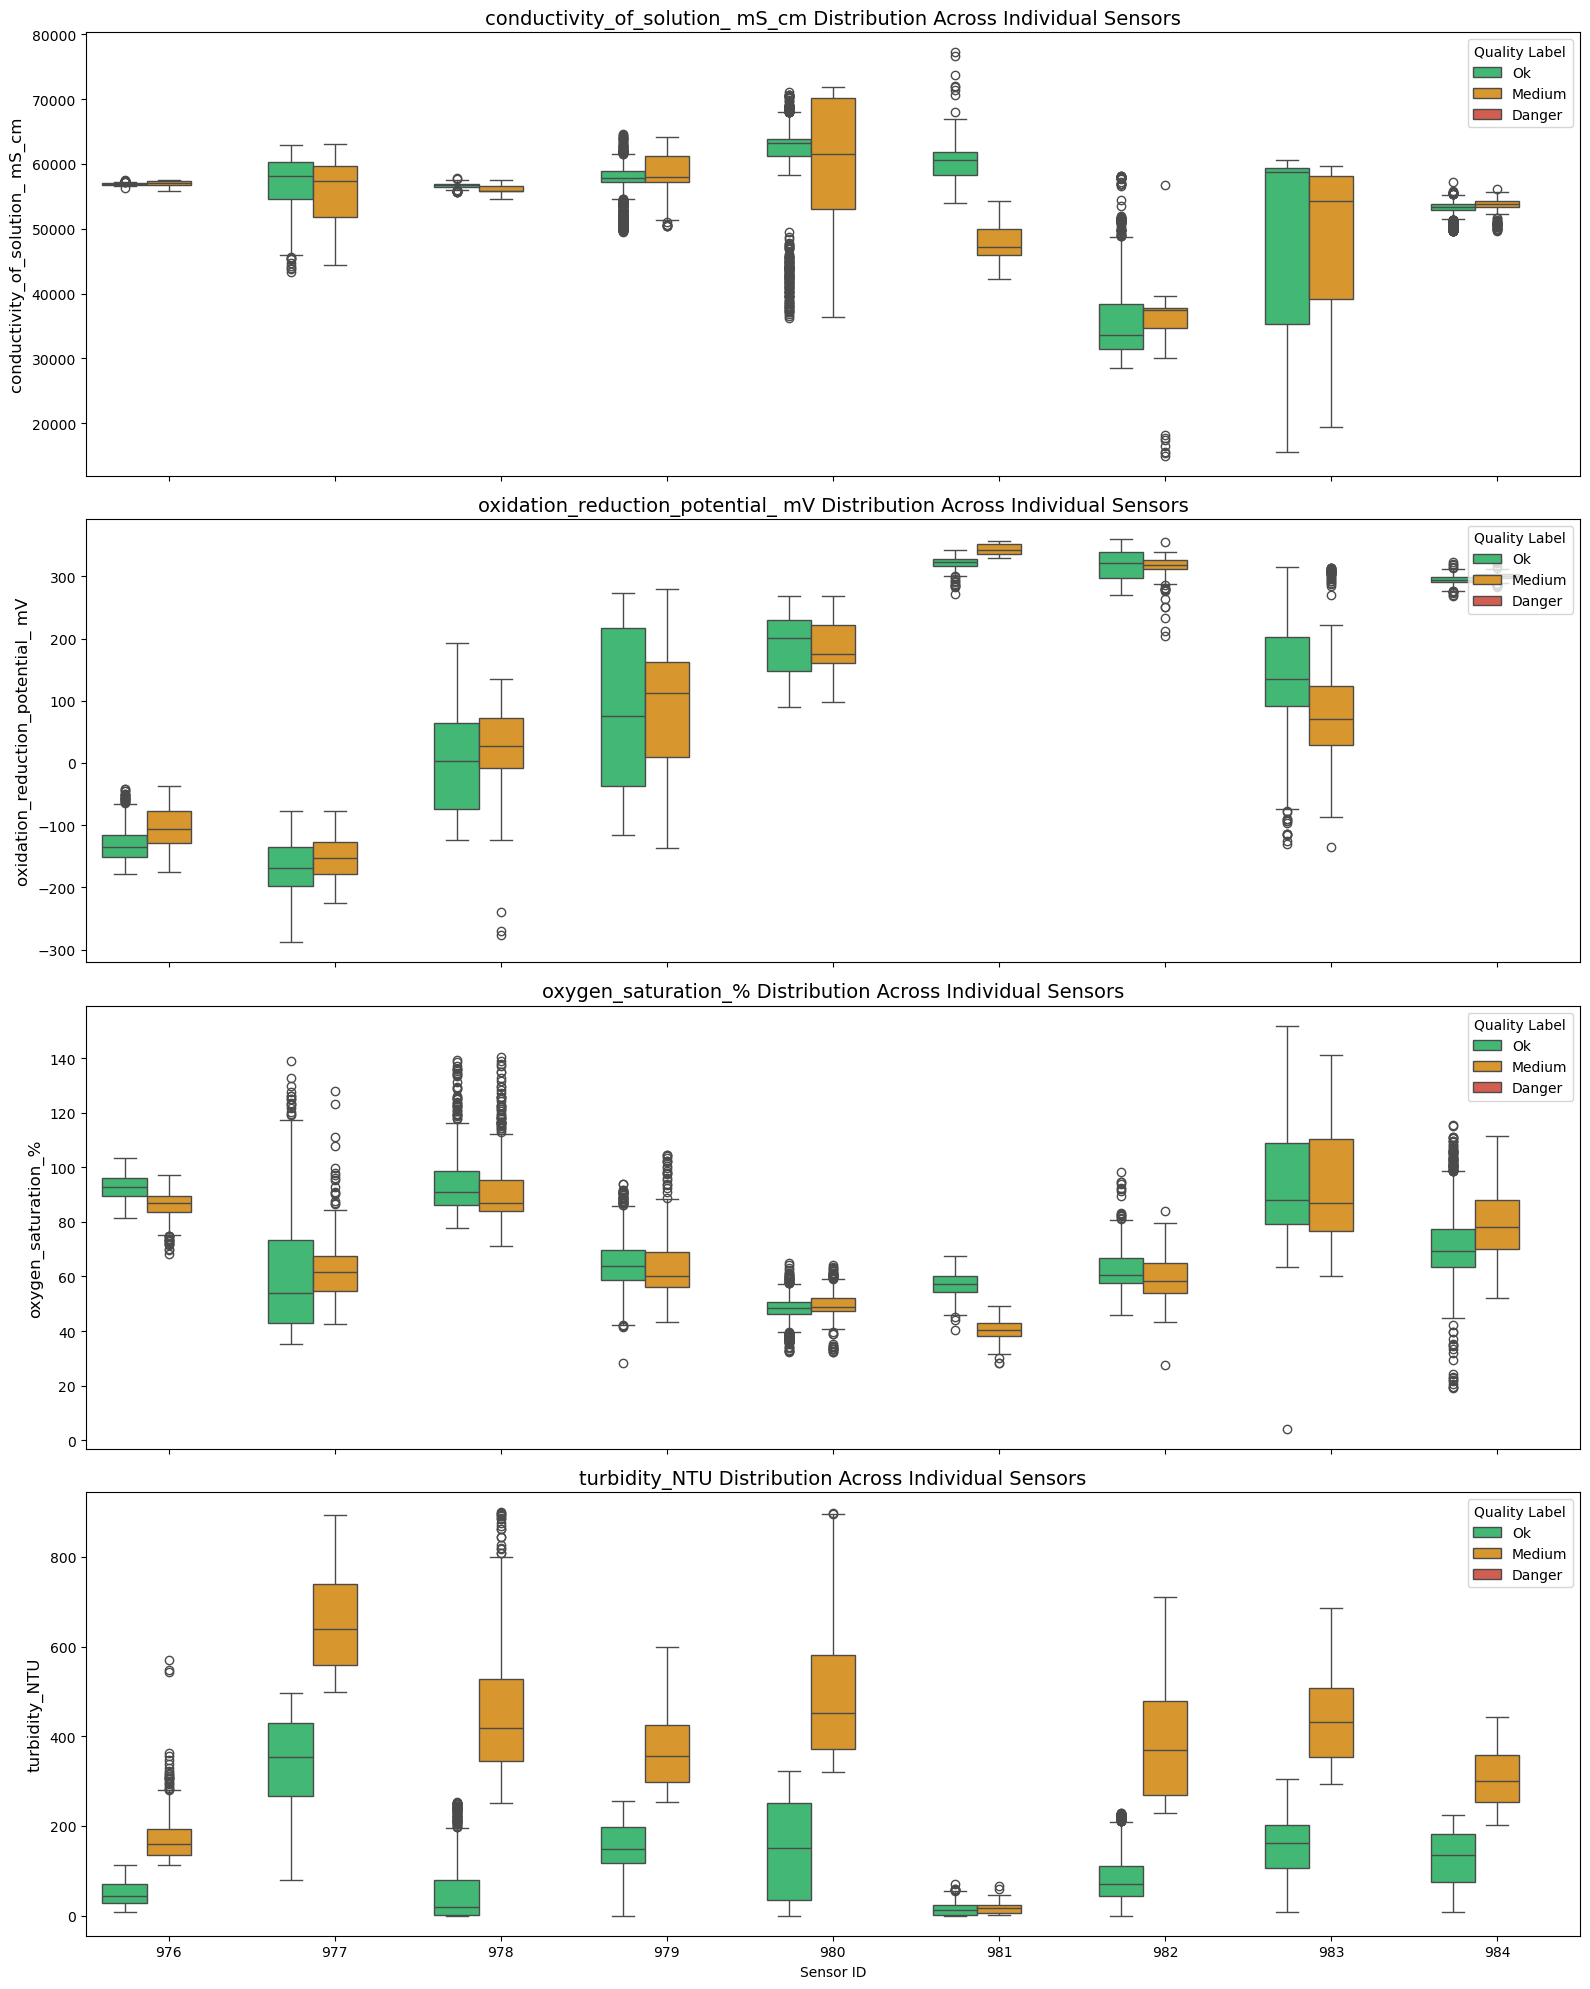

In [33]:
fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=True)
label_order = ['Ok', 'Medium', 'Danger']
palette = {'Ok': '#2ecc71', 'Medium': '#f39c12', 'Danger': '#e74c3c'} # Green, Orange, Red
# Sort Sensor IDs so the X-axis stays consistently ordered
sensor_order = sorted(final_training_df['sensor_id'].unique())

for i, metric in enumerate(features):
    sns.boxplot(
        data=final_training_df,
        x='sensor_id',
        y=metric,
        hue='Water_Quality_Label',
        hue_order=label_order,
        palette=palette,
        order=sensor_order,
        ax=axes[i]
    )
    axes[i].set_title(f'{metric} Distribution Across Individual Sensors', fontsize=14)
    axes[i].set_xlabel('Sensor ID' if i == 3 else '') # Only show label on the bottom plot
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].legend(title='Quality Label', loc='upper right')

plt.tight_layout()
plt.show()